# Recommender Systems

In this lab, we'll be using Keras to build a recommender system. We'll be using the MovieLens dataset, a common benchmark dataset for recommender systems. 

MovieLens is a web-based recommender system and virtual community that recommends movies for its users to watch, based on their film preferences using collaborative filtering of members' movie ratings and movie reviews. You can check out the website here: https://movielens.org/

We will download a subset of the dataset containing 100k ratings. There are tens of millions of ratings in the full dataset, spanning hundreds of thousands of users and movies. The subset we'll be using is a good example to demonstrate the concepts in this lab.

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from zipfile import ZipFile
from urllib.request import urlretrieve
from pathlib import Path

ML_100K_URL = "http://files.grouplens.org/datasets/movielens/ml-100k.zip"
ML_100K_FILENAME = Path("ml-100k.zip")
ML_100K_FOLDER = Path("ml-100k")

if not ML_100K_FOLDER.exists():
    if not ML_100K_FILENAME.exists():
        urlretrieve(ML_100K_URL, ML_100K_FILENAME.name)
    with ZipFile(ML_100K_FILENAME.name) as zip_file:
        zip_file.extractall()

The goal of MovieLens is to enable models to predict the rating a user would give to a movie they have not yet watched. This is a classic example of a recommendation system. The dataset is huge, and contains many parts giving information about the movies, the users, and the ratings. To begin with, we will look at the ratings file. Each line in the ratings file (u.data) is formatted as:

`user_id, item_id, rating, timestamp`

Which tells us a single user's rating of a single movie.

We will start by loading the ratings data into a pandas dataframe and then take a look at the first few rows. If you haven't used Pandas before, it's an extremely powerful library for dealing with tabular data. You can think of it as a Python version of Excel.

In [3]:
import pandas as pd

raw_ratings = pd.read_csv(ML_100K_FOLDER / "u.data", sep='\t',
                          names=["user_id", "item_id", "rating", "timestamp"])
raw_ratings

,user_id,item_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596
...,...,...,...,...
99995,880,476,3,880175444
99996,716,204,5,879795543
99997,276,1090,1,874795795
99998,13,225,2,882399156


In [4]:
# Number of users
raw_ratings['user_id'].unique().shape

(943,)

In [5]:
# Number of movies
raw_ratings['item_id'].unique().shape

(1682,)

The second file we'll look at is the movie metadata. This file (u.item) contains information about each movie, including the title and release date. Each line in the file is formatted as:

`movie_id | movie_title | release_date | video_release_date | IMDb_URL | unknown | Action | Adventure | Animation | Children's | Comedy | Crime | Documentary | Drama | Fantasy | Film-Noir | Horror | Musical | Mystery | Romance | Sci-Fi | Thriller | War | Western`

As you can see, the genres are binary variables. As with one-hot encoding, a 1 indicates that the movie is of that genre, and a 0 indicates that it is not. We aren't going to work with the genre data in this lab, but it's easy to imagine that it could be useful in a real-world recommendation system.

In [6]:
columns_to_keep = ['item_id', 'title', 'release_date', 'video_release_date', 'imdb_url']
items = pd.read_csv(ML_100K_FOLDER / "u.item", sep='|', names=columns_to_keep,
                    encoding='latin-1', usecols=range(5))
items

,item_id,title,release_date,video_release_date,imdb_url
0,1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...
1,2,GoldenEye (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?GoldenEye%20(...
2,3,Four Rooms (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Four%20Rooms%...
3,4,Get Shorty (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Get%20Shorty%...
4,5,Copycat (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Copycat%20(1995)
...,...,...,...,...,...
1677,1678,Mat' i syn (1997),06-Feb-1998,NaN,http://us.imdb.com/M/title-exact?Mat%27+i+syn+...
1678,1679,B. Monkey (1998),06-Feb-1998,NaN,http://us.imdb.com/M/title-exact?B%2E+Monkey+(...
1679,1680,Sliding Doors (1998),01-Jan-1998,NaN,http://us.imdb.com/Title?Sliding+Doors+(1998)
1680,1681,You So Crazy (1994),01-Jan-1994,NaN,http://us.imdb.com/M/title-exact?You%20So%20Cr...


In [7]:
# Number of items
items['item_id'].unique().shape

(1682,)

In [8]:
# Number of movie titles
items['title'].unique().shape

(1664,)

By default, the `release_date` column is a string. We can convert it to a `datetime` object using the `pd.to_datetime` function. This will make it easier to work with in the future (if we want to do things like check which date came first, for example).
 
We can also extract the year from the date and store it in a separate column. This will make it easier to do things like plot the number of movies released each year.

In [9]:
items['release_date'] = pd.to_datetime(items['release_date']) # Pandas makes this easy!
items['release_year'] = items['release_date'].dt.year # For later use

For our purposes, it will be easier to work with the data if we merge our two dataframes into a single dataframe. We can do this using the `merge` method. We'll merge the `items` dataframe into the `raw_ratings` dataframe, using the `item_id` column as the key. This will add the movie title and release year to each rating.

In [10]:
all_ratings = pd.merge(items, raw_ratings)

In [11]:
all_ratings.head()

,item_id,title,release_date,video_release_date,imdb_url,release_year,user_id,rating,timestamp
0,1,Toy Story (1995),1995-01-01,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,1995.0,308,4,887736532
1,1,Toy Story (1995),1995-01-01,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,1995.0,287,5,875334088
2,1,Toy Story (1995),1995-01-01,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,1995.0,148,4,877019411
3,1,Toy Story (1995),1995-01-01,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,1995.0,280,4,891700426
4,1,Toy Story (1995),1995-01-01,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,1995.0,66,3,883601324


### Data preprocessing

It's always important to understand the data you've collected. Thankfully, Pandas continues to make this easy for us. Using the `describe` method, we can get a quick statistical summary of the data.

In [30]:
all_ratings.describe()

,item_id,popularity,release_date,video_release_date,release_year,user_id,rating,timestamp
count,100000.000000,100000.000000,99991,0.0,99991.000000,100000.00000,100000.000000,1.000000e+05
mean,425.530130,168.071900,1988-02-09 00:43:11.369223296,NaN,1987.956216,462.48475,3.529860,8.835289e+08
min,1.000000,1.000000,1922-01-01 00:00:00,NaN,1922.000000,1.00000,1.000000,8.747247e+08
25%,175.000000,71.000000,1986-01-01 00:00:00,NaN,1986.000000,254.00000,3.000000,8.794487e+08
50%,322.000000,145.000000,1994-01-01 00:00:00,NaN,1994.000000,447.00000,4.000000,8.828269e+08
75%,631.000000,239.000000,1996-09-28 00:00:00,NaN,1996.000000,682.00000,4.000000,8.882600e+08
max,1682.000000,583.000000,1998-10-23 00:00:00,NaN,1998.000000,943.00000,5.000000,8.932866e+08
std,330.798356,121.784558,NaN,NaN,14.155523,266.61442,1.125674,5.343856e+06


Let's do a bit more pandas magic to compute the popularity of each movie (number of ratings). We will use the `groupby` method to group the dataframe by the `item_id` column and then use the `size` method to compute the number of ratings for each movie. We will use the `reset_index` method to convert the resulting Series into a dataframe with an `item_id` column.

In [31]:
popularity = all_ratings.groupby('item_id').size().reset_index(name='popularity')
items = pd.merge(popularity, items)

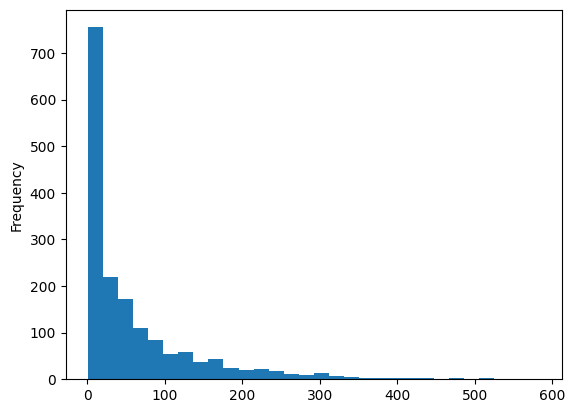

In [32]:
items['popularity'].plot.hist(bins=30);

In [33]:
(items['popularity'] == 1).sum() # Number of movies with only one rating

141

In [34]:
items.nlargest(10, 'popularity')[['title', 'popularity']] # Get the 10 most popular movies

,title,popularity
49,Star Wars (1977),583
257,Contact (1997),509
99,Fargo (1996),508
180,Return of the Jedi (1983),507
293,Liar Liar (1997),485
285,"English Patient, The (1996)",481
287,Scream (1996),478
0,Toy Story (1995),452
299,Air Force One (1997),431
120,Independence Day (ID4) (1996),429


In [35]:
all_ratings = pd.merge(popularity, all_ratings)
all_ratings.describe()

,item_id,popularity,release_date,video_release_date,release_year,user_id,rating,timestamp
count,100000.000000,100000.000000,99991,0.0,99991.000000,100000.00000,100000.000000,1.000000e+05
mean,425.530130,168.071900,1988-02-09 00:43:11.369223296,NaN,1987.956216,462.48475,3.529860,8.835289e+08
min,1.000000,1.000000,1922-01-01 00:00:00,NaN,1922.000000,1.00000,1.000000,8.747247e+08
25%,175.000000,71.000000,1986-01-01 00:00:00,NaN,1986.000000,254.00000,3.000000,8.794487e+08
50%,322.000000,145.000000,1994-01-01 00:00:00,NaN,1994.000000,447.00000,4.000000,8.828269e+08
75%,631.000000,239.000000,1996-09-28 00:00:00,NaN,1996.000000,682.00000,4.000000,8.882600e+08
max,1682.000000,583.000000,1998-10-23 00:00:00,NaN,1998.000000,943.00000,5.000000,8.932866e+08
std,330.798356,121.784558,NaN,NaN,14.155523,266.61442,1.125674,5.343856e+06


In [36]:
indexed_items = items.set_index('item_id')

In [37]:
all_ratings.head()

,item_id,popularity,title,release_date,video_release_date,imdb_url,release_year,user_id,rating,timestamp
0,1,452,Toy Story (1995),1995-01-01,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,1995.0,308,4,887736532
1,1,452,Toy Story (1995),1995-01-01,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,1995.0,287,5,875334088
2,1,452,Toy Story (1995),1995-01-01,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,1995.0,148,4,877019411
3,1,452,Toy Story (1995),1995-01-01,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,1995.0,280,4,891700426
4,1,452,Toy Story (1995),1995-01-01,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,1995.0,66,3,883601324


**Purging of Records needed**

In [38]:
# There are 1664 unique movie titles with 1682 item_id. Some movie titles are repeated with different item_ids
all_ratings.groupby('title').size().shape

(1664,)

Movies and item_id to be consolidated

In [39]:
# Create a mapping of titles to their unique item_ids
title_id_map = all_ratings.groupby('title')['item_id'].unique()
# Filter only those with more than one item_id
duplicated_titles = title_id_map[title_id_map.apply(lambda x: len(x) > 1)]
print(duplicated_titles)

title
Body Snatchers (1993)               [573, 670]
Butcher Boy, The (1998)           [1645, 1650]
Chairman of the Board (1998)      [1234, 1654]
Chasing Amy (1997)                  [246, 268]
Deceiver (1997)                    [309, 1606]
Designated Mourner, The (1997)    [1256, 1257]
Desperate Measures (1998)           [329, 348]
Fly Away Home (1996)                [304, 500]
Hugo Pool (1997)                  [1175, 1617]
Hurricane Streets (1998)          [1395, 1607]
Ice Storm, The (1997)               [305, 865]
Kull the Conqueror (1997)           [266, 680]
Money Talks (1997)                  [876, 881]
Nightwatch (1997)                 [1477, 1625]
Sliding Doors (1998)              [1429, 1680]
Substance of Fire, The (1996)      [711, 1658]
That Darn Cat! (1997)              [878, 1003]
Ulee's Gold (1997)                  [297, 303]
Name: item_id, dtype: object


Also, when above in Data Preprocessing, in window code number 10, we defined "popularity" through

popularity = all_ratings.groupby('item_id').size().reset_index(name='popularity');  items = pd.merge(popularity, items)

we ended up with some titles having two different popularities, see table below.

In [40]:
# Find titles with more than one unique item_id
title_id_map = all_ratings.groupby('title')['item_id'].unique()
duplicated_titles = title_id_map[title_id_map.apply(lambda x: len(x) > 1)]

# Filter original DataFrame for just those titles
filtered = all_ratings[all_ratings['title'].isin(duplicated_titles.index)]

# Drop duplicates so you're only seeing each item_id once per title
deduped = filtered[['title', 'item_id', 'popularity']].drop_duplicates()

# Sort for clarity
deduped_sorted = deduped.sort_values('title')

print(deduped_sorted)

                                title  item_id  popularity
77652           Body Snatchers (1993)      670          36
71629           Body Snatchers (1993)      573          33
99957         Butcher Boy, The (1998)     1650           1
99951         Butcher Boy, The (1998)     1645           1
97814    Chairman of the Board (1998)     1234           8
99963    Chairman of the Board (1998)     1654           1
38022              Chasing Amy (1997)      246         124
40719              Chasing Amy (1997)      268         255
99865                 Deceiver (1997)     1606           1
48274                 Deceiver (1997)      309          28
98051  Designated Mourner, The (1997)     1257           4
98048  Designated Mourner, The (1997)     1256           3
52978       Desperate Measures (1998)      348          27
51342       Desperate Measures (1998)      329          45
65878            Fly Away Home (1996)      500          31
47724            Fly Away Home (1996)      304         1

One option to avoid that would be to define popularity from title instead than from item_id:

popularity = all_ratings.groupby('title').size().reset_index(name='popularity');  items = pd.merge(popularity, items)

Or even better, at the beginning of data processing, we could have purged all_ratings and items from duplicates

**Quick Exercise**:

As we have seen, the `groupby` method is a powerful tool to quickly compute statistics on the data. Use it to compute the average rating for each movie.

**Hint**: you can use the `mean` method after the `groupby` method.

In [41]:
# Average rating for each movie
#all_ratings.groupby('title')['rating'].mean()

# Average rating for each movie, As Alex Olson did in class
all_ratings.groupby('title').agg(
    num_ratings=('rating', 'count'),
    avg_rating=('rating', 'mean')
)

# Average rating for each movie, expanding from above, for learning purposes
all_ratings.groupby('title').agg(
    num_ratings=('rating', 'count'),
    avg_rating=('rating', 'mean')
).sort_values('avg_rating', ascending=False)

# # Average rating for each movie, expanding from above, for learning purposes
# all_ratings.groupby('title').agg(
#     num_ratings=('rating', 'count'),
#     avg_rating=('rating', 'mean'),
#     num_ids=('item_id', 'nunique')
# ).sort_values('num_ids', ascending=False)

#raise NotImplementedError("Please calculate the average rating for each movie")

,num_ratings,avg_rating
title,,
They Made Me a Criminal (1939),1,5.0
Marlene Dietrich: Shadow and Light (1996),1,5.0
"Saint of Fort Washington, The (1993)",2,5.0
Someone Else's America (1995),1,5.0
Star Kid (1997),3,5.0
...,...,...
"Eye of Vichy, The (Oeil de Vichy, L') (1993)",1,1.0
King of New York (1990),1,1.0
Touki Bouki (Journey of the Hyena) (1973),1,1.0


Let's split the enriched data in a train / test split to make it possible to do predictive modeling:

In [42]:
from sklearn.model_selection import train_test_split

ratings_train, ratings_test = train_test_split(
    all_ratings, test_size=0.2, random_state=0)

user_id_train = np.array(ratings_train['user_id'])
item_id_train = np.array(ratings_train['item_id'])
rating_train = np.array(ratings_train['rating'])

user_id_test = np.array(ratings_test['user_id'])
item_id_test = np.array(ratings_test['item_id'])
rating_test = np.array(ratings_test['rating'])

The model uses item_id, where there are 1682-1664=18 duplicates. 18/1664=1% noise in the data. It would be better to clean the data at the beginning of the lab.

# Explicit feedback: supervised ratings prediction

Now let's begin to do some recommendation! We will build a model that takes a user and a movie as input and outputs a predicted rating. We will be taking advantage of embeddings to represent users and movies. That means that each movie and user will have an abstract representation in a continuous vector space. The model will learn these representations based on the ratings.

## Predictive ratings  as a regression problem

The following code implements the following architecture:

<img src="https://raw.githubusercontent.com/UofT-DSI/deep_learning/refs/heads/main/01_materials/labs/images/rec_archi_1.svg" style="width: 600px;" />

In [25]:
from tensorflow.keras.layers import Embedding, Flatten, Dense, Dropout
from tensorflow.keras.layers import Dot
from tensorflow.keras.models import Model

In [26]:
# For each sample we input the integer identifiers
# of a single user and a single item
class RegressionModel(Model):
    def __init__(self, embedding_size, max_user_id, max_item_id):
        super().__init__()
        
        self.user_embedding = Embedding(output_dim=embedding_size,
                                        input_dim=max_user_id + 1,
                                        name='user_embedding')
        self.item_embedding = Embedding(output_dim=embedding_size,
                                        input_dim=max_item_id + 1,
                                        name='item_embedding')
        
        # The following two layers don't have parameters.
        self.flatten = Flatten()
        self.dot = Dot(axes=1)
        
    def call(self, inputs):
        user_inputs = inputs[0]
        item_inputs = inputs[1]
        
        user_vecs = self.flatten(self.user_embedding(user_inputs))
        item_vecs = self.flatten(self.item_embedding(item_inputs))
        
        y = self.dot([user_vecs, item_vecs])
        return y


model = RegressionModel(embedding_size=64, max_user_id=all_ratings['user_id'].max(), max_item_id=all_ratings['item_id'].max())
model.compile(optimizer="adam", loss='mae')

In [29]:
all_ratings['item_id'].max()

1682

### Monitoring runs

When training a model with Keras, we get a `history` object back that contains lots of information about the training run. We can use this to plot the training and validation loss to see how the model has improved during training.

In [26]:
%%time

# Training the model
history = model.fit([user_id_train, item_id_train], rating_train,
                    batch_size=64, epochs=10, validation_split=0.1,
                    shuffle=True)

Epoch 1/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 3.2870 - val_loss: 1.0344
Epoch 2/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.8952 - val_loss: 0.7902
Epoch 3/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.7523 - val_loss: 0.7636
Epoch 4/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.7239 - val_loss: 0.7587
Epoch 5/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.7003 - val_loss: 0.7478
Epoch 6/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.6831 - val_loss: 0.7409
Epoch 7/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.6632 - val_loss: 0.7422
Epoch 8/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.6439 - val_loss: 0.7398
Epoch 9/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.6217 - val_loss: 0.7408
Epoch 10/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.5995 - val_loss: 0.7419
CPU times: total: 34 s
Wall time: 27.7 s


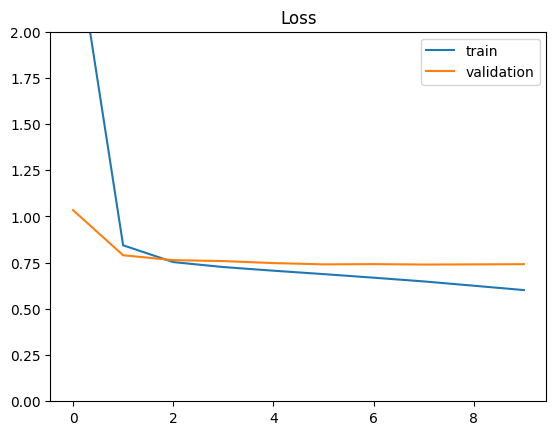

In [27]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='validation')
plt.ylim(0, 2)
plt.legend(loc='best')
plt.title('Loss');

**Questions**:

- Does it look like our model has overfit? Why or why not?  
Your Answer: Yes, because the progress in training and validation are slightly decoupled
- Suggest something we could do to prevent overfitting.  
Your Answer: We could introduce a droout layer, we could modify the learning rate, we could reduce the embedding_size. Also We could set a smaller batch_size, bigger validation_split.

Now that the model is trained, let's check out the quality of predictions:

In [28]:
def plot_predictions(y_true, y_pred):
    plt.figure(figsize=(4, 4))
    plt.xlim(-1, 6)
    plt.xlabel("True rating")
    plt.ylim(-1, 6)
    plt.ylabel("Predicted rating")
    plt.scatter(y_true, y_pred, s=60, alpha=0.01)

625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Final test MSE: 0.904
Final test MAE: 0.733


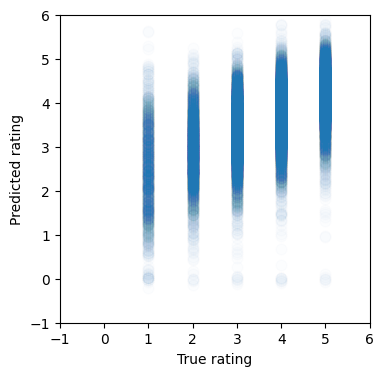

In [29]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

test_preds = model.predict([user_id_test, item_id_test])
print("Final test MSE: %0.3f" % mean_squared_error(test_preds, rating_test))
print("Final test MAE: %0.3f" % mean_absolute_error(test_preds, rating_test))
plot_predictions(rating_test, test_preds)

This graph shows us the range of predicted ratings our model gives, organized by the true rating. We can see that generally, the higher the true rating the higher the predicted rating, although there is quite a range of predictions for each instance. That's okay - our model is very simple, and human preferences are very complex!

Taking a look at the Mean Absolute Error, hopefully you got something around 0.75. This means that, on average, our predicted ratings are about 0.75 stars off from the true ratings. This is a pretty good result for a first attempt. We could probably do better with a more complex model, but we'll leave that for another time.

### Model Embeddings

Our model was built with two embedding layers. These layers have learned a representation of both the users and the movies in our dataset. We can extract these representations and use them to find similar movies or users. We can also do interesting exploratory analysis, like finding the most popular movies among our users, or finding the users that are most interested in a given movie.

In [30]:
# weights and shape
weights = model.get_weights()
[w.shape for w in weights]

[(944, 64), (1683, 64)]

In [31]:
user_embeddings = weights[0]
item_embeddings = weights[1]

In [32]:
item_id = 181
print(f"Title for item_id = {item_id}: {indexed_items['title'][item_id]}")

Title for item_id = 181: Return of the Jedi (1983)


In [33]:
print(f"Embedding vector for item_id={item_id}")
print(item_embeddings[item_id])
print("shape:", item_embeddings[item_id].shape)

Embedding vector for item_id=181
[ 0.5408359   0.11940353 -0.17901717 -0.03665054 -0.5818227  -0.2596886
 -0.31245947  0.16249661 -0.47128454  0.43019062  0.17241725  0.04747096
  0.3775421   0.01814952 -0.35970423  0.20744574 -0.32177132 -0.22301435
  0.27587292  0.4414122  -0.27940148  0.02462838  0.3269672   0.45055437
 -0.27557853 -0.22201486 -0.22487268 -0.42917055  0.4252236   0.07816808
 -0.27427694  0.30300167  0.27401492 -0.50791425  0.19404393  0.24749362
 -0.35797837  0.37756047  0.0730535  -0.3023082  -0.18660405 -0.38874403
  0.38481453 -0.32914     0.37851158  0.20735158  0.16192554 -0.04418722
 -0.2949652   0.22081852 -0.2882412  -0.5386634   0.36678115 -0.35487196
 -0.42249045 -0.17542651  0.36562684 -0.21195406  0.44507253 -0.2955367
 -0.3010857  -0.1453768   0.45827755  0.21859631]
shape: (64,)


As we discussed in lecture, our embeddings are not directly interpretable - we can't look at, say, a value of 0.297 in the embedding vector and say "this means that the movie is a drama". As an aside, there is a field of research dedicated to making _interpretable_ embeddings, but it's not something we'll cover in this course. 

### Finding our most similar items

Now we can have some fun, investigating the embeddings we've learned. We can start by finding the most similar items to a given item. We can do this by computing the cosine similarity between the item's embedding and the embedding of every other item. We can use the `cosine_similarity` function from `sklearn` to do this.

In [34]:
from sklearn.metrics.pairwise import cosine_similarity

def cosine(a, b):
    # Reshape to the shape our function expects
    a = a.reshape(1, -1)
    b = b.reshape(1, -1)
    return cosine_similarity(a, b)[0, 0]

In [35]:
def print_similarity(item_a, item_b, item_embeddings, titles):
    print(titles[item_a])
    print(titles[item_b])
    similarity = cosine(item_embeddings[item_a],
                        item_embeddings[item_b])
    print(f"Cosine similarity: {similarity:.3}")
    
print_similarity(50, 181, item_embeddings, indexed_items["title"])

Star Wars (1977)
Return of the Jedi (1983)
Cosine similarity: 0.917


It makes sense that the original Star Wars, and its later sequel Return of the Jedi have a high similarity. Let's try some other examples:

In [36]:
print_similarity(181, 288, item_embeddings, indexed_items["title"])

Return of the Jedi (1983)
Scream (1996)
Cosine similarity: 0.774


In [37]:
print_similarity(181, 1, item_embeddings, indexed_items["title"])

Return of the Jedi (1983)
Toy Story (1995)
Cosine similarity: 0.865


In [38]:
print_similarity(181, 181, item_embeddings, indexed_items["title"])

Return of the Jedi (1983)
Return of the Jedi (1983)
Cosine similarity: 1.0


*Quick Exercise*:

- Find some other films and compare their similarity. Do the results make sense to you? Can you find a pair of films that are very _dissimilar_?

In [39]:
# Code to help you search for a movie title
partial_title = "Copycat"
indexed_items[indexed_items['title'].str.contains(partial_title)]
#raise NotImplementedError("Please implement the next steps yourself")

,popularity,title,release_date,video_release_date,imdb_url,release_year
item_id,,,,,,
5,86,Copycat (1995),1995-01-01,NaN,http://us.imdb.com/M/title-exact?Copycat%20(1995),1995.0


In [40]:
print_similarity(4, 1682, item_embeddings, indexed_items["title"])

Get Shorty (1995)
Scream of Stone (Schrei aus Stein) (1991)
Cosine similarity: 0.814


In [41]:
print_similarity(5, 1681, item_embeddings, indexed_items["title"])

Copycat (1995)
You So Crazy (1994)
Cosine similarity: 0.756


In [42]:
results = pd.DataFrame(columns=["Item_id 1", "Item_id 2", "Cosine similarity"]); i=0
for id in range(1,100):
    for jd in range(1,100):
        results.loc[i] = [id, jd, cosine(item_embeddings[id],item_embeddings[jd])]
        i+=1
#results.sort_values('Cosine similarity')

Pair of films that are very _dissimilar_:

In [43]:
print_similarity(25, 35, item_embeddings, indexed_items["title"])

Birdcage, The (1996)
Free Willy 2: The Adventure Home (1995)
Cosine similarity: 0.491


In [44]:
print_similarity(14, 29, item_embeddings, indexed_items["title"])

Postino, Il (1994)
Batman Forever (1995)
Cosine similarity: 0.433


In [45]:
print_similarity(36, 50, item_embeddings, indexed_items["title"])

Mad Love (1995)
Star Wars (1977)
Cosine similarity: 0.489


Sometimes, even without knowing anything about a user, we can recommend films by asking them about a film that they do like. The code below compares the similarity of a given film to all others, and returns the most similar films.

In [46]:
def most_similar(item_id, item_embeddings, titles,
                 top_n=30):
    # Compute the cosine similarity between the item and all other items
    sims = cosine_similarity(item_embeddings[item_id].reshape(1, -1),
                             item_embeddings).ravel()
    
    # [::-1] makes it possible to reverse the order of a numpy
    # array, this is required because most similar items have
    # a larger cosine similarity value
    sorted_indexes = np.argsort(sims)[::-1]
    idxs = sorted_indexes[0:top_n]
    return list(zip(idxs, titles[idxs], sims[idxs]))

# Find the most similar films to "Star Wars"
most_similar(50, item_embeddings, indexed_items["title"], top_n=10)

[(50, 'Star Wars (1977)', 1.0000001),
 (181, 'Return of the Jedi (1983)', 0.91729796),
 (174, 'Raiders of the Lost Ark (1981)', 0.9148683),
 (172, 'Empire Strikes Back, The (1980)', 0.9061496),
 (12, 'Usual Suspects, The (1995)', 0.90555584),
 (96, 'Terminator 2: Judgment Day (1991)', 0.87176836),
 (204, 'Back to the Future (1985)', 0.871222),
 (64, 'Shawshank Redemption, The (1994)', 0.8704664),
 (183, 'Alien (1979)', 0.8694827),
 (423, 'E.T. the Extra-Terrestrial (1982)', 0.86812407)]

In [47]:
# Find the most similar films to "Star Trek VI: The Undiscovered Country"
most_similar(227, item_embeddings, indexed_items["title"], top_n=10)

[(227, 'Star Trek VI: The Undiscovered Country (1991)', 1.0),
 (228, 'Star Trek: The Wrath of Khan (1982)', 0.9011137),
 (439, 'Amityville: A New Generation (1993)', 0.87370265),
 (230, 'Star Trek IV: The Voyage Home (1986)', 0.86294),
 (1550, 'Destiny Turns on the Radio (1995)', 0.85116875),
 (787, 'Roommates (1995)', 0.8483014),
 (195, 'Terminator, The (1984)', 0.84806466),
 (1046, 'Malice (1993)', 0.84424454),
 (109, 'Mystery Science Theater 3000: The Movie (1996)', 0.84307516),
 (1012, 'Private Parts (1997)', 0.8322196)]

The similarities do not always make sense: the number of ratings is low and the embedding  does not automatically capture semantic relationships in that context. Better representations arise with higher number of ratings, and less overfitting  in models or maybe better loss function, such as those based on implicit feedback.

### Visualizing embeddings using TSNE

The [t-SNE](https://en.wikipedia.org/wiki/T-distributed_stochastic_neighbor_embedding) algorithm enables us to visualize high dimensional vectors in a 2D space by preserving local neighborhoods. We can use it to get a 2D visualization of the item embeddings and see if similar items are close in the embedding space.

In [48]:
from sklearn.manifold import TSNE

item_tsne = TSNE(learning_rate="auto", init="pca", perplexity=30).fit_transform(item_embeddings)

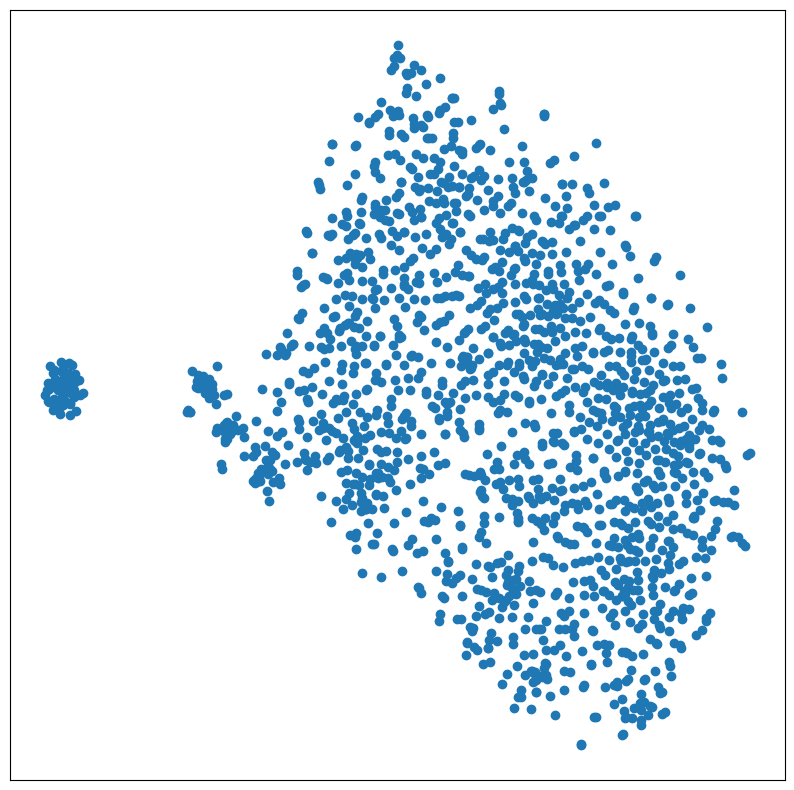

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
plt.scatter(item_tsne[:, 0], item_tsne[:, 1]);
plt.xticks(()); plt.yticks(());
plt.show()

In [50]:
# pip install plotly
import plotly.express as px

tsne_df = pd.DataFrame(item_tsne, columns=["tsne_1", "tsne_2"])
tsne_df["item_id"] = np.arange(item_tsne.shape[0])
tsne_df = tsne_df.merge(items.reset_index())

px.scatter(tsne_df, x="tsne_1", y="tsne_2",
           color="popularity",
           hover_data=["item_id", "title", "popularity"])

### Exercises

 - Add another layer to the neural network and retrain, compare train/test error.
 - Try adding more dropout and change layer sizes.


In [51]:
# For each sample we input the integer identifiers
# of a single user and a single item
class RegressionModelWithDense(Model):
    def __init__(self, embedding_size, max_user_id, max_item_id):
        super().__init__()
        self.user_embedding = Embedding(output_dim=embedding_size,
                                        input_dim=max_user_id + 1,
                                        name='user_embedding')
        self.item_embedding = Embedding(output_dim=embedding_size,
                                        input_dim=max_item_id + 1,
                                        name='item_embedding')
        self.flatten = Flatten()
        self.dot = Dot(axes=1)
        self.dense = Dense(64, activation='relu')          # New layer added
        self.dropout = Dropout(0.25)                         # Regularization
        self.output_layer = Dense(1, activation='linear')

    def call(self, inputs):
        user_inputs = inputs[0]
        item_inputs = inputs[1]
        user_vecs = self.flatten(self.user_embedding(user_inputs))
        item_vecs = self.flatten(self.item_embedding(item_inputs))
        interaction = self.dot([user_vecs, item_vecs])

        x = self.dense(interaction)
        x = self.dropout(x)
        output = self.output_layer(x)
        return output

model_with_dense = RegressionModelWithDense(embedding_size=64, max_user_id=all_ratings['user_id'].max(), max_item_id=all_ratings['item_id'].max())
model_with_dense.compile(optimizer="adam", loss='mae')

In [52]:
%%time

# Training the model
history_with_dense = model_with_dense.fit([user_id_train, item_id_train], rating_train,
                    batch_size=64, epochs=10, validation_split=0.1,
                    shuffle=True)

Epoch 1/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 1.6613 - val_loss: 0.7859
Epoch 2/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.6305 - val_loss: 0.7771
Epoch 3/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.4960 - val_loss: 0.7840
Epoch 4/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.4170 - val_loss: 0.7992
Epoch 5/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.3615 - val_loss: 0.8168
Epoch 6/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.3231 - val_loss: 0.8254
Epoch 7/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.2937 - val_loss: 0.8421
Epoch 8/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.2737 - val_loss: 0.8454
Epoch 9/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.2556 - val_loss: 0.8552
Epoch 10/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.2428 - val_loss: 0.8548
CPU times: total: 36.7 s
Wall time: 32.3 s


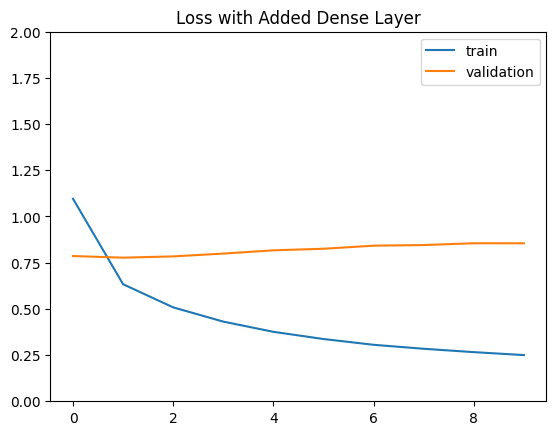

In [53]:
plt.plot(history_with_dense.history['loss'], label='train')
plt.plot(history_with_dense.history['val_loss'], label='validation')
plt.ylim(0, 2)
plt.legend(loc='best')
plt.title('Loss with Added Dense Layer');

625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Final test MSE: 1.218
Final test MAE: 0.853


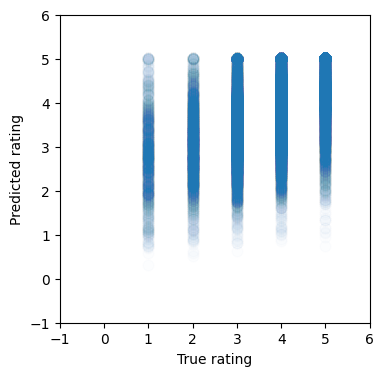

In [54]:
test_preds = model_with_dense.predict([user_id_test, item_id_test])
print("Final test MSE: %0.3f" % mean_squared_error(test_preds, rating_test))
print("Final test MAE: %0.3f" % mean_absolute_error(test_preds, rating_test))
plot_predictions(rating_test, test_preds)

My previous error with the model were:

Final test MSE: 0.905; Final test MAE: 0.734

After adding an extra layer to the model (Dense(64), Dropout(0.25)), the error worsened:

Final test MSE: 1.201; Final test MAE: 0.845

In pursue of " - Try adding more dropout and change layer sizes.", I set (Dense(128), Dropout(0.50)) and still did not improved the baseline model:

Final test MSE: 1.197; Final test MAE: 0.843

One more time, I set (Dense(1024), Dropout(0.80)) and still did not improved the baseline model:

Final test MSE: 1.217; Final test MAE: 0.830

### A recommendation function for a given user

Once the model is trained, the system can be used to recommend a few items for a user that they haven't seen before. The following code does that.

- we use the `model.predict` to compute the ratings a user would have given to all items
- we build a function that sorts these items and excludes those the user has already seen.

In [55]:
def recommend(user_id, top_n=10):
    item_ids = range(1, items['item_id'].max())
    seen_mask = all_ratings["user_id"] == user_id
    seen_movies = set(all_ratings[seen_mask]["item_id"])
    item_ids = list(filter(lambda x: x not in seen_movies, item_ids))

    user = np.zeros_like(item_ids)
    user[:len(item_ids)] = user_id
    items_ = np.array(item_ids)
    ratings = model.predict([user, items_]).flatten()
    top_items = ratings.argsort()[-top_n:][::-1]
    return [(indexed_items.loc[item_id]["title"], ratings[item_id]) for item_id in top_items]

In [56]:
for title, pred_rating in recommend(5):
    print("    %0.1f: %s" % (pred_rating, title))

48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
    4.2: Dead Man Walking (1995)
    4.1: Terminator 2: Judgment Day (1991)
    4.1: 20,000 Leagues Under the Sea (1954)
    4.0: Faster Pussycat! Kill! Kill! (1965)
    4.0: Young Guns (1988)
    3.9: Letter From Death Row, A (1998)
    3.9: Eat Drink Man Woman (1994)
    3.8: Clockwork Orange, A (1971)
    3.8: 2001: A Space Odyssey (1968)
    3.8: Jerry Maguire (1996)


### Exercises

- Try modifying our neural network to improve recommendation. You could try adding more layers, or using a different loss function. 
- Your goal is to improve the Mean Absolute Error on the test set. Show the results of your best model.

In [57]:
# Extend and improve the model below
class RegressionModel(Model):
    def __init__(self, embedding_size, max_user_id, max_item_id):
        super().__init__()

        self.user_embedding = Embedding(output_dim=embedding_size,
                                        input_dim=max_user_id + 1,
                                        name='user_embedding')
        self.item_embedding = Embedding(output_dim=embedding_size,
                                        input_dim=max_item_id + 1,
                                        name='item_embedding')

        # The following two layers don't have parameters.
        self.flatten = Flatten()
        self.dot = Dot(axes=1)
        self.dense1 = Dense(4, activation='relu')          # New layer added
        self.dropout1 = Dropout(0.5)                         # Regularization
        self.dense2 = Dense(4, activation='relu')          # New layer added
        self.dropout2 = Dropout(0.5)                         # Regularization
        self.dense3 = Dense(4, activation='relu')          # New layer added
        self.dropout3 = Dropout(0.5)                         # Regularization
        self.output_layer = Dense(1, activation='linear')

    def call(self, inputs):
        user_inputs = inputs[0]
        item_inputs = inputs[1]
        user_vecs = self.flatten(self.user_embedding(user_inputs))
        item_vecs = self.flatten(self.item_embedding(item_inputs))
        interaction = self.dot([user_vecs, item_vecs])

        x = self.dense1(interaction)
        x = self.dropout1(x)
        x = self.dense2(x)
        x = self.dropout2(x)
        x = self.dense3(x)
        x = self.dropout3(x)
        output = self.output_layer(x)
        return output


model = RegressionModel(embedding_size=64, max_user_id=all_ratings['user_id'].max(), max_item_id=all_ratings['item_id'].max())
model.compile(optimizer="adam", loss='mse')

In [58]:
%%time
# Training the model
history = model.fit([user_id_train, item_id_train], rating_train,
                    batch_size=64, epochs=10, validation_split=0.1,
                    shuffle=True)

Epoch 1/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 7.7011 - val_loss: 1.0079
Epoch 2/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.7106 - val_loss: 0.9637
Epoch 3/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.3378 - val_loss: 1.0768
Epoch 4/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.2004 - val_loss: 1.1378
Epoch 5/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.1464 - val_loss: 1.2053
Epoch 6/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.1216 - val_loss: 1.2366
Epoch 7/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.1085 - val_loss: 1.2772
Epoch 8/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0936 - val_loss: 1.3010
Epoch 9/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0815 - val_loss: 1.3220
Epoch 10/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0742 - val_loss: 1.3371
CPU times: total: 39.7 s
Wall time: 39 s


Text(0.5, 1.0, 'Loss')

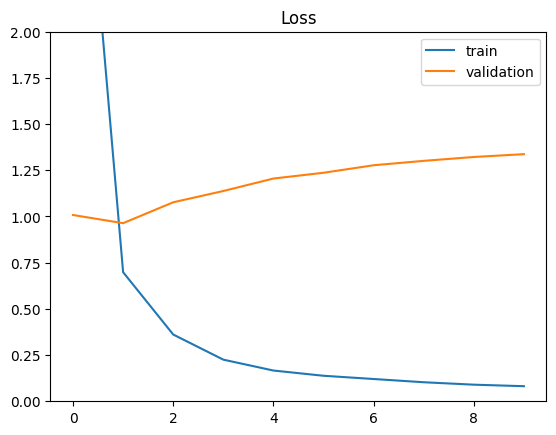

In [59]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='validation')
plt.ylim(0, 2)
plt.legend(loc='best')
plt.title('Loss')

625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Final test MSE: 1.323
Final test MAE: 0.891


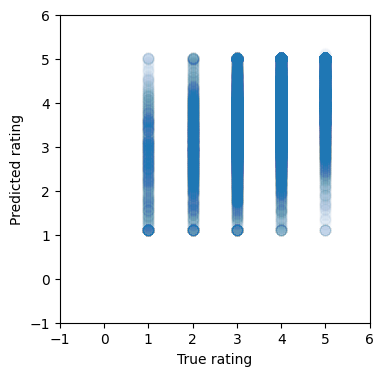

In [60]:
test_preds = model.predict([user_id_test, item_id_test])
print("Final test MSE: %0.3f" % mean_squared_error(test_preds, rating_test))
print("Final test MAE: %0.3f" % mean_absolute_error(test_preds, rating_test))
plot_predictions(rating_test, test_preds)

Baseline model with loss='mse', I got: Final test MSE: 0.879; Final test MAE: 0.732, which slightly improves the baseline

I tried with 3 Dense layers and different sizes and dropouts, it does not look it helps, overfitting gets worse.

My best model is the baseline with loss 'mse', with test MSE: 0.879 and test MAE: 0.732, which slightly improves the baseline. Model as below:

In [61]:
# For each sample we input the integer identifiers
# of a single user and a single item
class RegressionModel(Model):
    def __init__(self, embedding_size, max_user_id, max_item_id):
        super().__init__()
        
        self.user_embedding = Embedding(output_dim=embedding_size,
                                        input_dim=max_user_id + 1,
                                        name='user_embedding')
        self.item_embedding = Embedding(output_dim=embedding_size,
                                        input_dim=max_item_id + 1,
                                        name='item_embedding')
        
        # The following two layers don't have parameters.
        self.flatten = Flatten()
        self.dot = Dot(axes=1)
        
    def call(self, inputs):
        user_inputs = inputs[0]
        item_inputs = inputs[1]
        
        user_vecs = self.flatten(self.user_embedding(user_inputs))
        item_vecs = self.flatten(self.item_embedding(item_inputs))
        
        y = self.dot([user_vecs, item_vecs])
        return y


model = RegressionModel(embedding_size=64, max_user_id=all_ratings['user_id'].max(), max_item_id=all_ratings['item_id'].max())
model.compile(optimizer="adam", loss='mse')